# CNN model - evaluacija

## 1. Uvod
- Konvoluciona neuronska mreža (CNN – Convolutional Neural Network) je tip duboke neuronske mreže koja se najčešće koristi za analizu podataka koji imaju prostornu ili vremensku strukturu, poput slika, video zapisa i spektrograma zvuka.
Za razliku od klasičnih potpuno povezanih mreža, CNN koristi konvolucione slojeve koji automatski uče lokalne obrasce i karakteristike u podacima — na primer, promene u frekvenciji, intenzitetu i ritmu u audio signalu.

- U ovom projektu, CNN je korišćen za prepoznavanje emocija iz govora, gde se svaka audio datoteka pretvara u Mel-spektrogram — dvodimenzionalni prikaz energije po frekvencijama kroz vreme.
CNN model zatim analizira te spektrogramske obrasce i uči da razlikuje emocije poput happy, sad, angry, fear, calm i druge.

- Zahvaljujući sposobnosti da automatski izdvoji relevantne karakteristike i prepozna kompleksne nelinearne odnose u podacima, CNN se pokazao kao veoma efikasan pristup za zadatke audio klasifikacije i prepoznavanja emocija.

## 2. Pretprocesiranje
- Podaci su podeljeni na train, validation i test skup.

- Svaki audio zapis je pretvoren u Mel spektrogram dimenzija (n_frames, 128).

- Labelama (emocijama) je izvršen Label Encoding i zatim One-hot encoding za rad sa neuronskom mrežom.

- Ako je potrebno, matrice su proširene dimenzijom (np.newaxis) da bi CNN mogao da ih obradi kao 3D tenzore.

In [ ]:

duration = 3      # seconds
sr = 44100
n_mels = 128
hop_length = 512

# ===============================
# LOAD CSV
# ===============================
df = pd.read_csv(csv_path)

# ===============================
# EXTRACT MEL SPECTROGRAMS
# ===============================
features = []
labels = []
max_frames = 0

for path, label in tqdm(zip(df['path'], df['emotion']), total=len(df), desc="Extracting features"):
    y, _ = librosa.load(path, sr=sr, duration=duration, offset=0.5, res_type='kaiser_fast')
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=8000, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel)
    mel_db = mel_db.T  # (frames, n_mels)
    
    features.append(mel_db.astype(np.float32))
    labels.append(label)
    max_frames = max(max_frames, mel_db.shape[0])

# ===============================
# PAD / TRIM
# ===============================
features_padded = []
for f in features:
    if f.shape[0] < max_frames:
        f_padded = np.pad(f, ((0,max_frames-f.shape[0]),(0,0)), mode='constant')
    else:
        f_padded = f[:max_frames, :]
    features_padded.append(f_padded)

X_all = np.array(features_padded, dtype=np.float32)
y_all = np.array(labels)

# ===============================
# STANDARDIZE po mel bins
# ===============================
n_samples, n_frames, n_mels = X_all.shape
X_all = X_all.reshape(-1, n_mels)
scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)
X_all = X_all.reshape(n_samples, n_frames, n_mels)

# SAVE scaler
joblib.dump(scaler, os.path.join(output_dir, "cnn_scaler.pkl"))

# ===============================
# SPLIT 70/15/15
# ===============================
train_idx, temp_idx = train_test_split(np.arange(len(y_all)), test_size=0.3, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

## 3. Arhitektura modela
1. Conv1D(64, kernel_size=20, activation='relu', input_shape=input_shape)

    - Prvi konvolucioni sloj sa 64 filtera i veličinom kernela 20.

    - Detektuje osnovne obrasce u vremenskom domenu audio signala (npr. promene energije i osnovne frekvencijske karakteristike).

    - Aktivaciona funkcija ReLU (Rectified Linear Unit) uvodi nelinearnost u model i pomaže da mreža uči složenije obrasce.

2. Conv1D(128, kernel_size=20, activation='relu', kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01))

    - Drugi konvolucioni sloj sa 128 filtera.

    - Dodaje L2 regularizaciju koja sprečava prenaučenost (overfitting) tako što penalizuje prevelike težine modela.

    - Uči složenije obrasce, kao što su kombinacije osnovnih frekvencijskih struktura i emotivnih tonova.

3. MaxPooling1D(pool_size=8)

    - Smanjuje dimenzionalnost tako što uzima maksimalnu vrednost u okviru svakog segmenta duž vremenske ose.

    - Time se čuvaju najvažnije karakteristike i model postaje otporniji na šum i manje varijacije u govoru.

4. Dropout(0.4)

    - Tokom treniranja, nasumično “isključuje” 40% neurona da bi se sprečilo preveliko oslanjanje na određene jedinice.

    - Ova tehnika značajno smanjuje rizik od overfittinga.

5. Conv1D(128, kernel_size=20, activation='relu')

Treći konvolucioni sloj dodatno produbljuje model i omogućava mreži da uči abstraktnije obrasce u signalima (npr. specifične emotivne tonove i intonacije).

6. MaxPooling1D(pool_size=8)

    - Ponovo smanjuje dimenzionalnost i čuva najizraženije informacije.

    - Omogućava efikasnije procesiranje i smanjuje broj parametara.

7. Dropout(0.4)

    - Još jedan sloj za regularizaciju koji dodatno sprečava prenaučenost.

8. GlobalAveragePooling1D()

    - Zamenjuje klasični Flatten sloj, tako što računa prosek vrednosti svake mape karakteristika.

    - Na taj način smanjuje broj parametara i poboljšava generalizaciju modela.

9. Dense(256, activation='relu')

    - Potpuno povezani sloj sa 256 neurona.

    - Kombinuje sve prethodno naučene karakteristike i priprema ih za klasifikaciju.

    - Aktivacija ReLU se koristi za nelinearnost.

10. Dropout(0.4)

    - Još jedan sloj regularizacije za dodatnu otpornost modela.

11. Dense(num_classes, activation='softmax')

    - Izlazni sloj koji ima onoliko neurona koliko ima klasa emocija (npr. 8).

    - Aktivacija Softmax pretvara izlaz u verovatnoće po klasama, što omogućava interpretaciju koji je emocionalni izraz najverovatniji za dati audio uzorak.

In [ ]:
input_shape = X_train.shape[1:]  # (259, 128)

model = Sequential([
    Conv1D(64, kernel_size=20, activation='relu', input_shape=input_shape),
    Conv1D(128, kernel_size=20, activation='relu', kernel_regularizer=l2(0.01), 
    bias_regularizer=l2(0.01)), 
    MaxPooling1D(pool_size=8), 
    Dropout(0.4),
    Conv1D(128, kernel_size=20, activation='relu'), 
    MaxPooling1D(pool_size=8), 
    Dropout(0.4), 
    GlobalAveragePooling1D(),
    Dense(256, activation='relu'),
    Dropout(0.4), 
    Dense(num_classes, activation='softmax')
])

opt = Adam(learning_rate=0.0001)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
model.summary()

## 4. Trening CNN modela
- Model je treniran pomoću:

    - epochs = 50

    - batch_size = 64

    - validation_data = (X_val, y_val)

- Tokom treninga se prati gubitak i tačnost na train i validation skupovima.
- Model se zatim čuva kao "cnn_model.h5" i kasnije je omogućena evaluacija na osnovu kreiranog modela.

In [ ]:
history = model.fit(
    X_train, y_train_enc,
    validation_data=(X_val, y_val_enc),
    epochs=50,
    batch_size=64
)

model.save("cnn_model.h5")

## 5. Evaluacija na test skupu

- Model se evaluira nad test skupom pomoću model.evaluate, što vraća loss i accuracy.

- Rezultati se štampaju u konzolu.

- Predikcija i konfuzione matrice:

    - Predikcije se dobijaju preko model.predict.

    - Na osnovu predikcija se kreira confusion matrix sa sklearn.metrics.confusion_matrix.

    - Matrica konfuzije se vizualizuje i čuva kao slika confusion_matrix_eval.png.

    - Dodatni metrički prikaz

    - Računa se i klasična accuracy metrika preko accuracy_score iz sklearn za dodatnu proveru.


In [ ]:
import numpy as np
from tensorflow.keras import load_model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# ===============================
# Učitaj prethodno trenirani model
# ===============================
model = load_model("cnn_model.h5")

# ===============================
# Učitaj test podatke
# ===============================
X_test  = np.load("../data/processsed_data/cnn/X_test_cnn.npy")
y_test  = np.load("../data/processed_data/cnn/y_test_cnn.npy")

# Ako su podaci 2D, dodaj kanal dimenziju
X_test = X_test[:, :, np.newaxis] if X_test.ndim==2 else X_test

# ===============================
# 3️⃣ One-hot encoding labela
# ===============================
# Napomena: moraš koristiti isti LabelEncoder koji je korišćen prilikom treniranja
emotion_labels = ["neutral","calm","happy","sad","angry","fearful","disgust","surprised"]
le = LabelEncoder()
le.fit(emotion_labels)  # isto kao prilikom treniranja

y_test_int = le.transform(y_test)
num_classes = len(le.classes_)
y_test_enc = to_categorical(y_test_int, num_classes=num_classes)

# ===============================
# Evaluacija modela
# ===============================
test_loss, test_acc = model.evaluate(X_test, y_test_enc, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# ===============================
# Predikcija i konfuzione matrice
# ===============================
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_enc, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_labels)

plt.figure(figsize=(10,8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Emotions")
plt.savefig("confusion_matrix_eval.png")
plt.show()

# ===============================
# Dodatni metrici po potrebi
# ===============================
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy (sklearn): {accuracy*100:.2f}%")


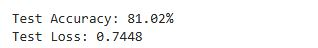

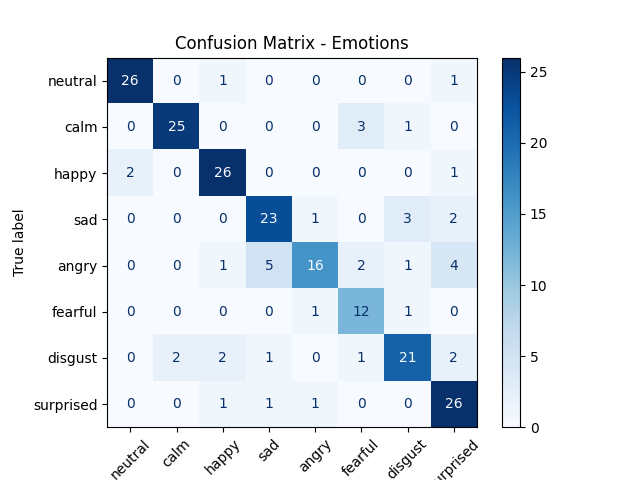

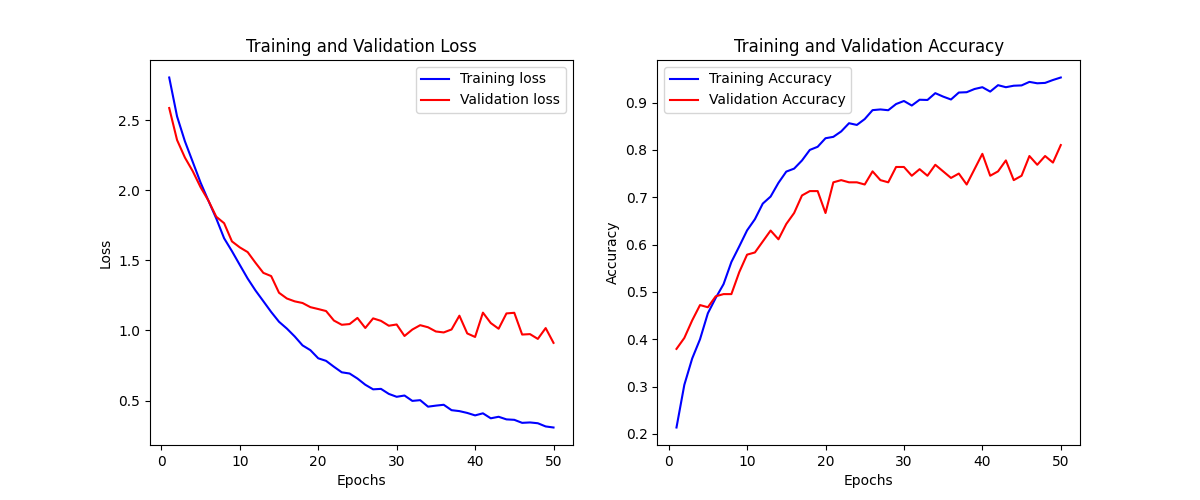

In [1]:
from IPython.display import Image, display

# Ime slike 
acc = "models/cnn/cnn.jpg"
matrix="models/cnn/confusion_matrix.png"
plot="models/cnn/accuracy_plot.png"
# Prikaz slike
display(Image(filename=acc))
display(Image(filename=matrix))
display(Image(filename=plot))

## * Augmentacija
- Koraci:

    1. Podešavanja – učitavaju se CSV sa putanjama audio fajlova, sample rate, dužina uzorka i StandardScaler za normalizaciju.

    2. Augmentacija – primenjuju se funkcije: dodavanje šuma, pomeranje signala, time-stretch, pitch shift i promena jačine zvuka.

    3. Ekstrakcija Mel spektrograma – za svaki augmentovani signal generiše se spektrogram u dB skali i transponuje da dimenzija vremenskih frejmova bude prva.

    4. Normalizacija – spektrogrami se skaliraju sa prethodno sačuvanim StandardScaler-om.

    5. Čuvanje podataka – rezultujući augmentovani i standardizovani podaci se čuvaju u .npy fajlove (X_train_cnn.npy i y_train_cnn.npy).

- Rezultat: augmentovani trening set spreman za CNN model.

In [ ]:
def add_noise(y): return y + 0.005 * np.random.randn(len(y))
def time_shift(y): return np.roll(y, np.random.randint(-int(len(y)*0.2), int(len(y)*0.2)))
def stretch(y): return librosa.effects.time_stretch(y, rate=np.random.uniform(0.8,1.2))
def pitch_shift(y, sr): return librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.uniform(-2,2))
def dynamic_change(y): return y * np.random.uniform(0.7,1.3)

n_samples, n_frames, n_mels = X_train_aug.shape
X_train_aug = X_train_aug.reshape(-1, n_mels)
X_train_aug = scaler.transform(X_train_aug)
X_train_aug = X_train_aug.reshape(n_samples, n_frames, n_mels)

np.save(os.path.join(output_dir,"X_train_cnn.npy"), X_train_aug)
np.save(os.path.join(output_dir,"y_train_cnn.npy"), y_train_aug)

## Rezultati pre augmentacije

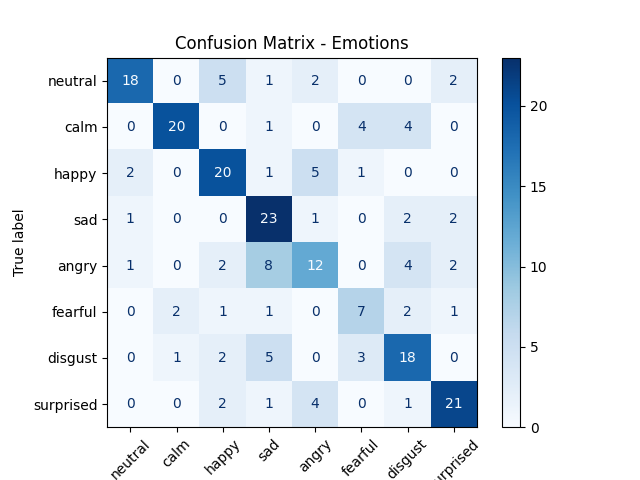

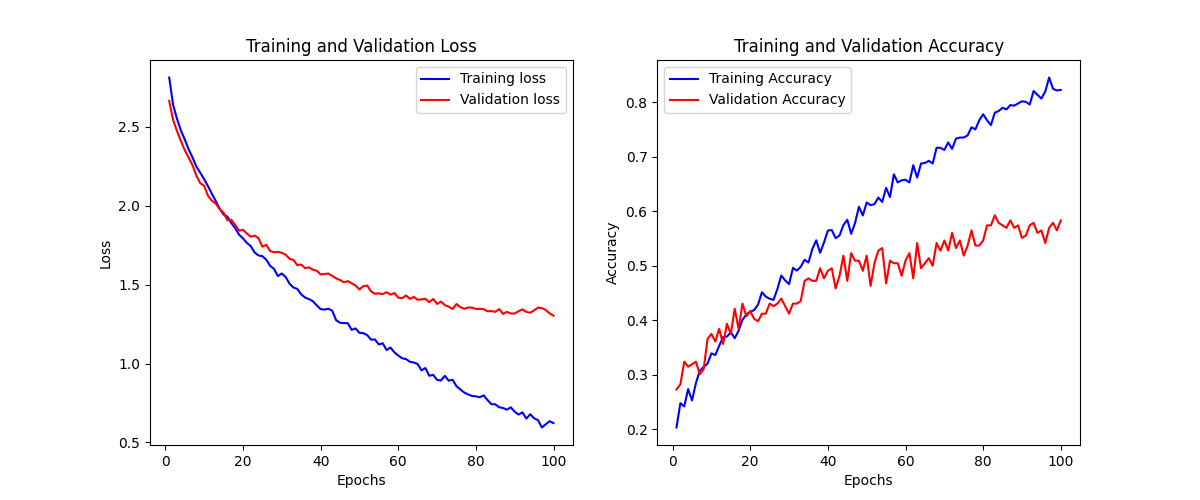

In [4]:
from IPython.display import Image, display

# Ime slike 
init = "models/cnn/init_confusion_matrix.png"
plot="models/cnn/init_accuracy_plot.png"
# Prikaz slike
display(Image(filename=init))
display(Image(filename=plot))

## Zaključak 
- Naš CNN model je postigao tačnost (accuracy) od 81.02% na test skupu, sa loss vrednošću od 0.7448. Ovi rezultati pokazuju da je model uspešno naučio relevantne karakteristike iz podataka i da može prilično precizno klasifikovati nove, neviđene primere.

- Zašto je ovo dobar rezultat:

    - Tačnost preko 80% na test skupu obično ukazuje na stabilan i generalizovan model.

    - Relativno nizak loss znači da model ne samo da je tačan, već i da su predviđene verovatnoće blizu stvarnih labela, što je važno za pouzdane klasifikacije.

- Najbolje karakteristike modela:

    - Dobro balansira složenost i generalizaciju, bez prekomernog overfittinga (ako loss na treningu nije previše manji od test loss-a).

    - Conv1D slojevi efikasno hvataju lokalne obrasce u podacima (npr. vremenske ili audio sekvence).

    - Dropout sloj i regularizacija pomažu u smanjenju overfittinga.

**Zaključak**: Model je pouzdan za predviđanje na sličnim podacima i može se koristiti kao osnova za dalje poboljšanje (npr. dodatnim slojevima, tuningom hiperparametara ili većim datasetom).